In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [3]:
df=pd.read_csv("C:\\creativa_datasets\\Adult Census Income.csv")

In [4]:
#create bin for age
#see unique for all categorical values

In [5]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


| **Column**         | **Description (English)**                           | **الشرح (بالعربية)**                                                                                                                     |
| ------------------ | --------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| **Age**            | Age of the individual                               | عمر الشخص بالسنوات.                                                                                                                      |
| **Workclass**      | Type of employment                                  | نوع جهة العمل، مثل: حكومي، خاص، يعمل لحسابه، أو بدون عمل.                                                                                |
| **fnlwgt**         | Final sampling weight assigned by the Census Bureau | وزن إحصائي يستخدمه مكتب الإحصاء الأمريكي لجعل العينة تمثل عددًا أكبر من السكان، وليس له معنى مباشر بالنسبة للفرد.                        |
| **Education**      | Highest education level achieved                    | أعلى مؤهل تعليمي حصل عليه الشخص (Bachelor's, HS-grad, Masters...).                                                                       |
| **education.num**  | Numerical representation of education level         | تمثيل رقمي لمستوى التعليم، حيث تعني القيمة الأكبر مستوى تعليميًا أعلى.                                                                   |
| **Marital.status** | Marital status                                      | الحالة الاجتماعية (أعزب، متزوج، مطلق، أرمل...).                                                                                          |
| **Occupation**     | Job or occupation                                   | المهنة أو الوظيفة التي يعمل بها الشخص.                                                                                                   |
| **Relationship**   | Relationship within the household                   | علاقة الشخص برب الأسرة (زوج، زوجة، ابن، غير ذلك...).                                                                                     |
| **Race**           | Race or ethnicity                                   | العِرق أو الأصل العرقي للشخص.                                                                                                            |
| **Sex**            | Gender                                              | الجنس (ذكر أو أنثى).                                                                                                                     |
| **Capital.gain**   | Profit from investments or sale of assets           | الأرباح الرأسمالية الناتجة عن بيع استثمارات أو أصول.                                                                                     |
| **Capital.loss**   | Loss from investments or sale of assets             | الخسائر الرأسمالية الناتجة عن بيع استثمارات أو أصول.                                                                                     |
| **Hours.per.week** | Average working hours per week                      | متوسط عدد ساعات العمل أسبوعيًا.                                                                                                          |
| **Native.country** | Country of origin                                   | الدولة الأصلية أو بلد الميلاد.                                                                                                           |
| **Income**         | Target variable indicating annual income            | **المتغير المستهدف (Target)**، ويحدد ما إذا كان دخل الشخص السنوي **أكثر من 50 ألف دولار (`>50K`)** أو **50 ألف دولار أو أقل (`<=50K`)**. |


In [6]:
#see if the datatype of each column is correct, if not we can change it using astype() method
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


(32561, 15)

In [7]:
df.drop(columns=['education'], inplace=True)

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [9]:
for col in cat_cols:
    print(f"unique values in Column: {col} {df[col].unique()}\n")
    

unique values in Column: workclass ['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']

unique values in Column: marital.status ['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']

unique values in Column: occupation ['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']

unique values in Column: relationship ['Not-in-family' 'Unmarried' 'Own-child' 'Other-relative' 'Husband' 'Wife']

unique values in Column: race ['White' 'Black' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']

unique values in Column: sex ['Female' 'Male']

unique values in Column: native.country ['United-States' '?' 'Mexico' 'Greece' 'Vietnam' 'China' 'Taiwan' 'India'
 'Philippines' 'Trinadad&Tobago' '

In [10]:
df.replace('?', np.nan, inplace=True)

In [11]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [12]:
df=df.dropna(subset=['occupation'])

In [13]:
impute=SimpleImputer(strategy='most_frequent')
df[['native.country']]=impute.fit_transform(df[['native.country']])



In [14]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

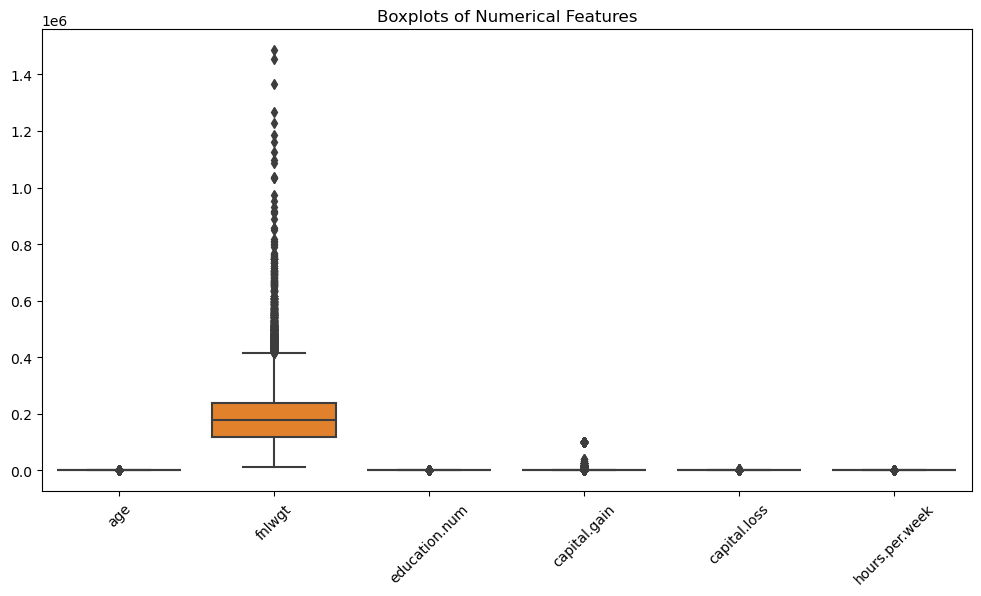

In [15]:
#check for outliers in numerical columns using boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

Encoding

In [16]:
cat_cols.remove('income')

In [17]:
cat_cols.remove('sex')

In [26]:
cat_cols

['workclass',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'native.country']

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(df[cat_cols])

In [19]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)
df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)


In [20]:
le = LabelEncoder()

df['income'] = le.fit_transform(df['income'])
df['sex'] = le.fit_transform(df['sex'])

Train-test split

In [21]:
X=df.drop(columns=['income'])
y=df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaling

In [ ]:
from sklearn.preprocessing import RobustScaler
#better for outliers than StandardScaler
scaler = RobustScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

model creation

In [23]:
from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      4614
           1       0.52      0.78      0.62      1530

    accuracy                           0.77      6144
   macro avg       0.72      0.77      0.73      6144
weighted avg       0.82      0.77      0.78      6144

[[3504 1110]
 [ 331 1199]]
0.7654622395833334


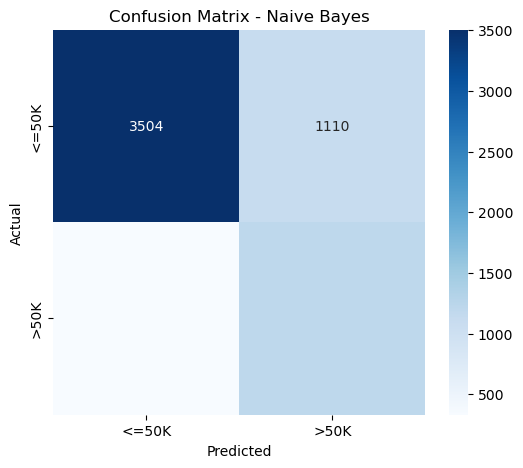

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [28]:
#logistic regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4614
           1       0.73      0.58      0.64      1530

    accuracy                           0.84      6144
   macro avg       0.80      0.75      0.77      6144
weighted avg       0.83      0.84      0.83      6144

[[4282  332]
 [ 648  882]]
0.8404947916666666


d:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
#random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4614
           1       0.74      0.62      0.67      1530

    accuracy                           0.85      6144
   macro avg       0.81      0.77      0.79      6144
weighted avg       0.85      0.85      0.85      6144

[[4288  326]
 [ 589  941]]
0.85107421875
